# 

In [153]:
from utilities.io_tools import input_tools
from utilities import boostHistHelpers as hh
import hist
import numpy as np
import matplotlib.pyplot as plt

In [14]:
scetlib_dyturboN3LL = input_tools.read_matched_scetlib_dyturbo_hist(
    "/scratch/submit/cms/kdlong/TheoryCorrections/SCETlib/ct18z_nplambda_n3+0ll/inclusive_Z_CT18Z_nplambda_N3+0LL_combined.pkl",
    "/scratch/submit/cms/kdlong/TheoryCorrections/SCETlib/ct18z_nplambda_scalevars/inclusive_Z_CT18Z_nplambda_scalevars_nnlo_sing_combined.pkl",
    "/scratch/submit/cms/kdlong/TheoryCorrections/DYTURBO/nnlo-scetlibmatch/scalevariations/z0/results_z-2d-nnlo-vj-CT18ZNNLO-{scale}-scetlibmatch.txt",
    axes=("Y", "qT"),
)

In [243]:
dyturboNNLO = input_tools.read_dyturbo_file("/scratch/submit/cms/kdlong/TheoryCorrections/DYTURBO/nnlo-scetlibmatch/scalevariations/z0/results_z-2d-nnlo-vj-CT18ZNNLO-mur1-muf1-scetlibmatch.txt")
dyturboNNLO = hh.makeAbsHist(dyturboNNLO, "Y")

In [244]:
scetlib_n4ll = hh.makeAbsHist(input_tools.read_scetlib_hist("/scratch/submit/cms/kdlong/TheoryCorrections/SCETlib/ct18z_nplambda_n4ll/inclusive_Z_CT18Z_nplambda_N4p0LL_NNLOJET_combined.pkl"), "Y")

In [245]:
scetlib_n3lo_sing = hh.makeAbsHist(input_tools.read_scetlib_hist("/scratch/submit/cms/kdlong/TheoryCorrections/SCETlib/ct18z_nplambda_n4ll/inclusive_Z_NNPDF31_nplambda_n3lo_sing.pkl"), "Y")
scetlib_nnlo_sing = hh.makeAbsHist(input_tools.read_scetlib_hist("/scratch/submit/cms/kdlong/TheoryCorrections/SCETlib/ct18z_nplambda_scalevars/inclusive_Z_CT18Z_nplambda_scalevars_nnlo_sing_combined.pkl"), "Y")


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f0ebf58c690>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

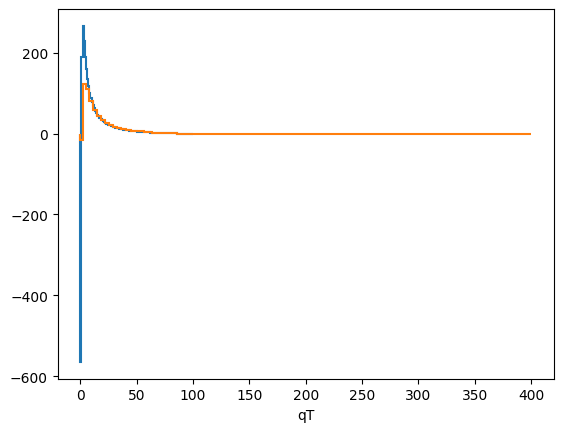

In [246]:
scetlib_nnlo_sing[{"vars" : 0}].project("qT").plot(binwnorm=1.)
scetlib_n3lo_sing[{"vars" : 0}].project("qT").plot(binwnorm=1.)

In [247]:
y1 = input_tools.read_text_data("/scratch/submit/cms/kdlong/TheoryCorrections/NNLOJET/results/PTZ/NNLO.ptz_yz0.dat")

In [266]:
n3lo = scetlib_n3lo_sing.copy()[:,:9,...]

In [267]:
nnlo = n3lo.copy()

In [277]:
for i in range(nnlo.axes["absY"].size):
    data = input_tools.read_text_data(f"/scratch/submit/cms/kdlong/TheoryCorrections/NNLOJET/results/PTZ/NNLO.ptz_yz{i}.dat")
    nnlo.values()[0,i,:,:] = data[:,3::2]*(data[:,2]-data[:,0])[:,np.newaxis]
    


In [280]:
for i in range(n3lo.axes["absY"].size):
    data = input_tools.read_text_data(f"/scratch/submit/cms/kdlong/TheoryCorrections/NNLOJET/results/PTZ/NNLO.ptz_yz{i}.dat")
    n3lo.values()[0,i,:,:] = data[:,3::2]*(data[:,2]-data[:,0])[:,np.newaxis]


In [278]:
yz_nnlo = hist.Hist(hist.axis.Regular(9, 0, 3.6, name="absY"), data=input_tools.read_text_data(f"/scratch/submit/cms/kdlong/TheoryCorrections/NNLOJET/results/Z/NNLO.abs_yz.dat")[:, 3])


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f0ebf4a6e50>, errorbar=None, legend_artist=None)]

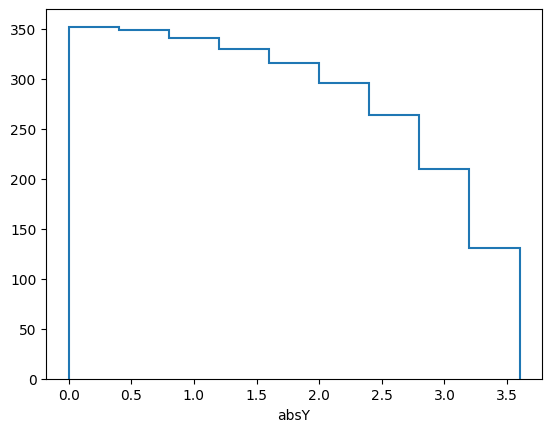

In [290]:
(yz_nnlo/1000).plot()

In [287]:
dyturboNNLO.sum()

WeightedSum(value=2415.27, variance=8.11699e-05)

In [279]:
yz_nnlo*0.4/dyturboNNLO.sum().value

Hist(Regular(9, 0, 3.6, name='absY'), storage=Double()) # Sum: 428.5405362581917

In [130]:
n4ll_n3lo = hh.addHists(scetlib_n4ll[{"vars" : 0}], -1*scetlib_n3lo_sing[{"vars" : 0}])
n4ll_n3lo = hh.addHists(n4ll_n3lo[:,:9,...], n3lo[{"vars" : 0}])

In [242]:
n3lo[{"vars" : 0}]/2000

Hist(
  Regular(1, 60, 120, name='Q'),
  Variable([0, 0.4, 0.8, 1.2, 1.6, 2, 2.4, 2.8, 3.2, 3.6], underflow=False, name='absY'),
  Variable(array([  0. ,   2.5,   5. ,   8. ,  11.4,  14.9,  18.5,  22. ,  25.5,
        29. ,  32.6,  36.4,  40.4,  44.9,  50.2,  56.4,  63.9,  73.4,
        85.4, 105. , 132. , 173. , 253. , 400. ]), name='qT'),
  storage=Weight()) # Sum: WeightedSum(value=17.3978, variance=1.29419e-11) (WeightedSum(value=17.4295, variance=1.38917e-11) with flow)

In [218]:
dyturboNNLO.project("qT")

Hist(Variable(array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100.]), underflow=False, name='qT'), storage=Weight()) # Sum: WeightedSum(value=2415.27, variance=8.11699e-05)

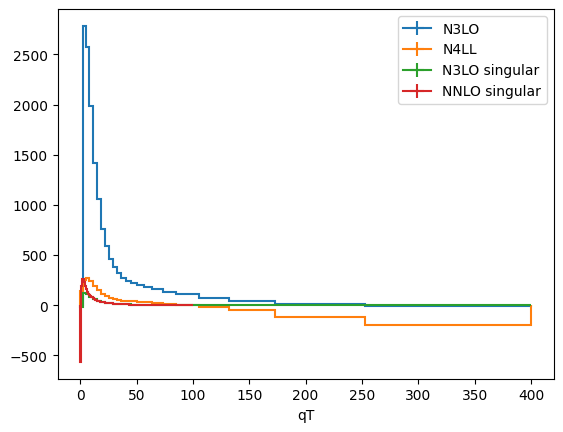

In [172]:
n3lo[{"vars" : 0 }].project("qT").plot(label="N3LO")
scetlib_n4ll[{"vars" : 0}].project("qT").plot(label="N4LL")
scetlib_n3lo_sing[{"vars" : 0}].project("qT").plot(binwnorm=1., label="N3LO singular")
scetlib_nnlo_sing[{"vars" : 0}].project("qT").plot(binwnorm=1., label="NNLO singular")
plt.legend()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f0ec5bb6250>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

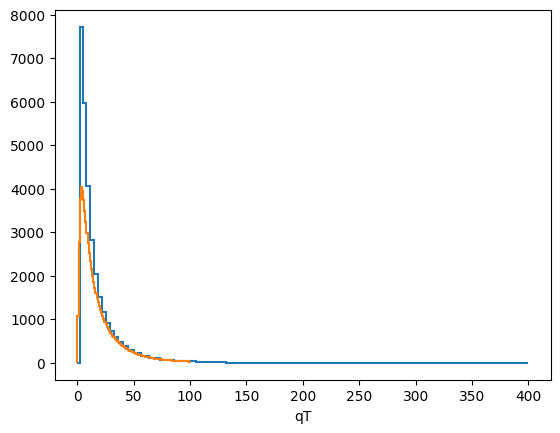

In [141]:
n3lo.project("qT").plot(binwnorm=1.)
scetlib_dyturboN3LL.project("qT").plot(binwnorm=1.)